In [1]:
# use holodeck environment

In [1]:
# making sure the notebook is run from the right directory, as lots of paths are relative to the root directory
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]

if not (PROJECT_ROOT / 'holodeck_output_lib_gp_mcmc').exists():
    raise RuntimeError("Please run Jupyter from the notebooks_and_files_for_final_results directory")


In [2]:
import holodeck as holo
import holodeck
from holodeck.constants import YR, NWTG, SPLC, GYR, PC, MSOL
from holodeck.galaxy_profiles import NFW
from holodeck import utils
from holodeck.librarian import DEF_NUM_FBINS, DEF_NUM_LOUDEST, DEF_PTA_DUR
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.integrate import solve_ivp, quad
import numpy as np
import kalepy as kale
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import os
import la_forge.core as co
from ceffyl.chain_utils import chain_utils
import la_forge.diagnostics as dg
from chainconsumer.chainconsumer import ChainConsumer
from emcee.autocorr import integrated_time

import numpy as np
import matplotlib.pyplot as plt

import corner
from matplotlib.lines import Line2D

PINT not installed. PINT or libstempo are required to use par and tim files.


## MCMC using GPs and NNs (figure 5)

for n_training:8000, mtot_array: [5.44e+09 2.40e+09 1.59e+09 1.06e+09 1.44e+07]
data.shape (97400, 20)
the chain is taken from the path: freq_bin2_mtot_1.59e+09_mrat_0.88_redz_0.87
updated chain length: (53267, 6)
for n_training:8000, mtot_array: [6.68e+09 3.61e+09 1.96e+09 1.59e+09 1.06e+09]
data.shape (127744, 20)
the chain is taken from the path: freq_bin3_mtot_1.59e+09_mrat_0.96_redz_1.05
updated chain length: (55922, 6)


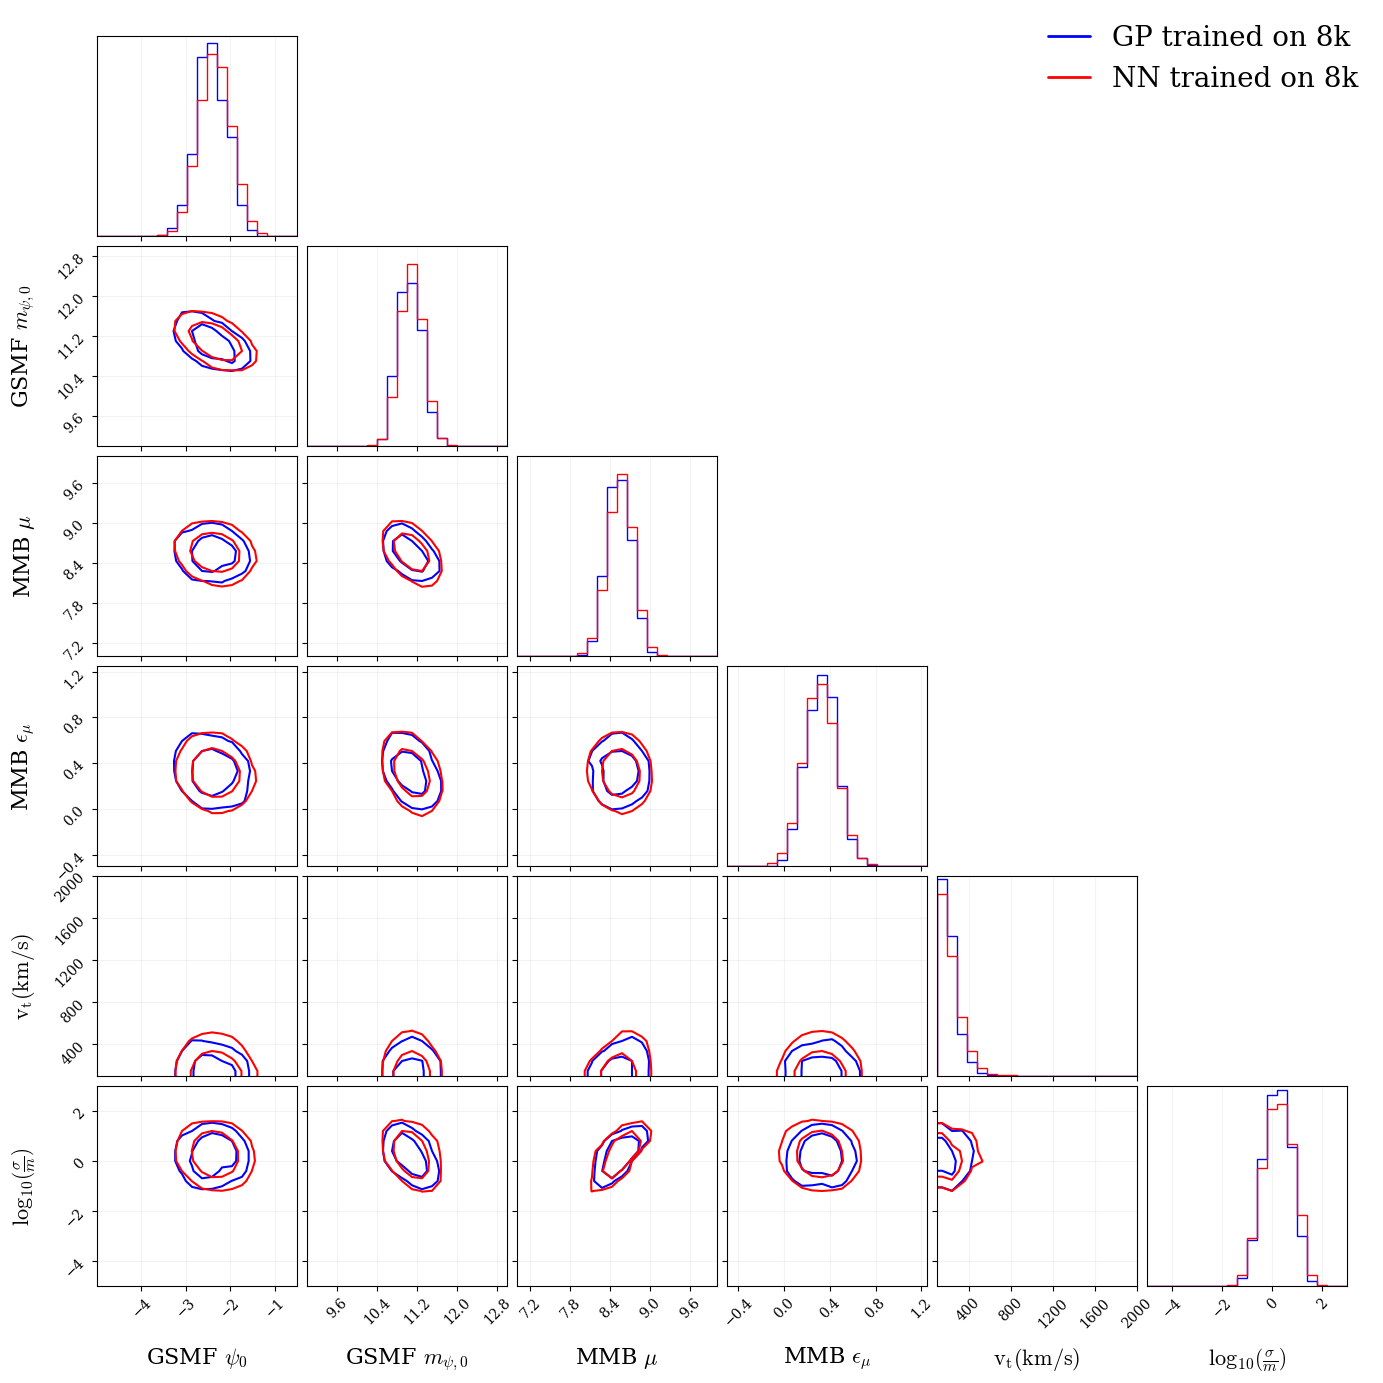

In [14]:
#### GP ##################################################
# mcmc using GP
gp_nn = 'gp'
PARAM_SPACE = 'PS_Classic_SIDM_Astro_Extended_Version2'
NSAMPLES = 8000
NREALS = 2000
NFREQS = 5
NFREQS_TRAINING = 5 # for gp training and ceffyl mcmc

# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'

# hd_mp_dp_curn_path = Path(OUTPUT).parent / 'gp_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'

max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'

# to have paths of all chains for max contri mqz

max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
print(
    f'for n_training:{NSAMPLES}, mtot_array: '
    f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
)
path_list = []
for i in range(len(mtot_array)):
    mtot = mtot_array[i] * MSOL
    mrat = mrat_array[i]
    redz = redz_array[i]
    new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'

    path_list.append(new_path_to_updated_txt_file) 

path_list
updated_chain_path = path_list[2] # choosing 3rd bin because max contri Mtot is 1.6e9, same as NN case
# updated_chain_path = path_list[-1]
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))

# for no constraints
# idx = np.where(data[:, 5] > 0)

# index 0 - psi0
# index 1 - gsmf_mchar0_log10
# index 2 - mmb_mamp_log10
# index 3 - mmb_scatter_dex
# index 4 - vt
# index 5 - sigma0_over_m_times_t_age_by_1Gyr
# index 6 - sigma0_over_m
# index 7 - tdf
# index 8 - sigma_over_m
# index 9 - y
# index 10 - v0

# corner with selected params
data_copy_8k_gp = data.copy()
data_copy_8k_gp = data_copy_8k_gp[idx[0], :]
data_copy_8k_gp[:, 8] = np.log10(data_copy_8k_gp[:, 8]) # for sigma/m
data_copy_8k_gp = data_copy_8k_gp[:, [0, 1, 2, 3, 4, 8]]

print(f'updated chain length: {data_copy_8k_gp.shape}')
# print(f'path to updated mcmc chain: {updated_chain_path}')

##### NN ####################################
gp_nn = 'nn'

PARAM_SPACE = 'PS_Classic_SIDM_Astro_Extended_Version2'
NSAMPLES = 8000
NREALS = 2000
NFREQS = 5
NFREQS_TRAINING = 5 # for gp training and ceffyl mcmc

# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'

hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'

max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'

# to have paths of all chains for max contri mqz

max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
print(
    f'for n_training:{NSAMPLES}, mtot_array: '
    f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
)
path_list = []
for i in range(len(mtot_array)):
    mtot = mtot_array[i] * MSOL
    mrat = mrat_array[i]
    redz = redz_array[i]
    new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'

    path_list.append(new_path_to_updated_txt_file) 

path_list
updated_chain_path = path_list[3] # choosing 4th bin because max contri Mtot is 1.6e9, same as GP case
# updated_chain_path = path_list[-1]
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))

# for no constraints
# idx = np.where(data[:, 5] > 0)

# corner with selected params
data_copy_8k_nn = data.copy()
data_copy_8k_nn = data_copy_8k_nn[idx[0], :]
data_copy_8k_nn[:, 8] = np.log10(data_copy_8k_nn[:, 8]) # for sigma/m
data_copy_8k_nn = data_copy_8k_nn[:, [0, 1, 2, 3, 4, 8]]

print(f'updated chain length: {data_copy_8k_nn.shape}')
#################################################################


labels = [r"GSMF $\psi_0$", r"GSMF $m_{\psi, 0}$", r"MMB $\mu$", r"MMB $\epsilon_{\mu}$", r"$\mathrm{v_t (km/s)}$", r"$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$"]

# Define x-axis limits
ranges = [(-5, -0.5), (9, 13), (7, 10), (-0.5, 1.25), (100, 2000), (-5, 3)] # changed the lower limit on vt chain from 0 to 100 to avoid the edge effect (29.10.2025)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig = corner.corner(
    data_copy_8k_gp,
    labels=labels,
    range=ranges,
    show_titles=False,
    fill_contours=False,
    plot_contours=True,
    plot_density=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='blue',
    hist_kwargs={
        "linestyle": "-",
        "linewidth": 1,
        "density": True
    }
)


# Generate the corner plot with partial limits
corner.corner(
    data_copy_8k_nn,
    fig=fig,
    labels=labels,
    show_titles=False,
    plot_density=False,
    plot_contours=True,
    fill_contours=False,  # This makes the contour regions filled with color
    # levels=[0.68, 0.95, 0.997],  # Confidence levels
    levels=[0.68, 0.95],  # Confidence levels
    plot_datapoints=False,      # ← turn off the scatter
    color='red',
    label_kwargs={"fontsize": 16},
    title_kwargs={"fontsize": 16, "loc": "left"},
    # fig=plt.figure(figsize=(6, 6)),
    range=ranges,  # Apply limits only to the first two
    hist_kwargs={
        "linestyle": "-",
        "linewidth":1,
        "density": True
    }
)


legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label=f'GP trained on 8k'),
    Line2D([0], [0], color='red', lw=2, label=f'NN trained on 8k')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=20,
    frameon=False
)

plt.show()


In [15]:
# median values table

def summary_stats(chain):
    median = np.median(chain, axis=0)
    p16 = np.percentile(chain, 16, axis=0)
    p84 = np.percentile(chain, 84, axis=0)
    return median, p16, p84

med_gp, p16_gp, p84_gp = summary_stats(data_copy_8k_gp)
med_nn, p16_nn, p84_nn = summary_stats(data_copy_8k_nn)

labels = [
    r"GSMF $\psi_0$",
    r"GSMF $m_{\psi, 0}$",
    r"MMB $\mu$",
    r"MMB $\epsilon_{\mu}$",
    r"$\mathrm{v_t (km/s)}$",
    r"$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$"
]

print(f"{'Parameter':<25} {'GP':>25} {'NN':>25}")
print("-"*80)

for i, name in enumerate(labels):
    gp_plus  = p84_gp[i] - med_gp[i]
    gp_minus = med_gp[i] - p16_gp[i]
    
    nn_plus  = p84_nn[i] - med_nn[i]
    nn_minus = med_nn[i] - p16_nn[i]
    
    gp_str = f"{med_gp[i]:.2f} (+{gp_plus:.2f}, -{gp_minus:.2f})"
    nn_str = f"{med_nn[i]:.2f} (+{nn_plus:.2f}, -{nn_minus:.2f})"
    
    print(f"{name:<25} {gp_str:>25} {nn_str:>25}")

Parameter                                        GP                        NN
--------------------------------------------------------------------------------
GSMF $\psi_0$                  -2.43 (+0.38, -0.31)      -2.34 (+0.37, -0.36)
GSMF $m_{\psi, 0}$             11.05 (+0.25, -0.23)      11.09 (+0.24, -0.23)
MMB $\mu$                       8.53 (+0.19, -0.18)       8.56 (+0.19, -0.19)
MMB $\epsilon_{\mu}$            0.33 (+0.13, -0.14)       0.31 (+0.14, -0.14)
$\mathrm{v_t (km/s)}$       183.37 (+93.50, -74.86)  184.37 (+130.28, -83.03)
$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$       0.22 (+0.56, -0.57)       0.26 (+0.62, -0.61)


In [16]:
# print latex code for the table
def latex_table_compare(labels, med_gp, p16_gp, p84_gp,
                       med_nn, p16_nn, p84_nn,
                       caption="SIDM model parameter constraints from MCMCs using: GP vs NN",
                       label="tab:sidm_posterior_median"):
    
    lines = []
    lines.append(r"\begin{table}")
    lines.append(r"\centering")
    lines.append(r"\renewcommand{\arraystretch}{1.6}")
    lines.append(r"\begin{tabular}{|l|r|r|}")
    lines.append(r"\hline")
    lines.append(r"Parameter & GP & NN \\")
    lines.append(r"\hline")
    
    for i, name in enumerate(labels):
        gp_plus  = p84_gp[i] - med_gp[i]
        gp_minus = med_gp[i] - p16_gp[i]
        
        nn_plus  = p84_nn[i] - med_nn[i]
        nn_minus = med_nn[i] - p16_nn[i]
        
        gp_str = f"${med_gp[i]:.2f}^{{+{gp_plus:.2f}}}_{{-{gp_minus:.2f}}}$"
        nn_str = f"${med_nn[i]:.2f}^{{+{nn_plus:.2f}}}_{{-{nn_minus:.2f}}}$"
        
        lines.append(f"{name} & {gp_str} & {nn_str} \\\\")
    
    lines.append(r"\hline")
    lines.append(r"\end{tabular}")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

latex_code = latex_table_compare(
    labels,
    med_gp, p16_gp, p84_gp,
    med_nn, p16_nn, p84_nn
)

print(latex_code)

\begin{table}
\centering
\renewcommand{\arraystretch}{1.6}
\begin{tabular}{|l|r|r|}
\hline
Parameter & GP & NN \\
\hline
GSMF $\psi_0$ & $-2.43^{+0.38}_{-0.31}$ & $-2.34^{+0.37}_{-0.36}$ \\
GSMF $m_{\psi, 0}$ & $11.05^{+0.25}_{-0.23}$ & $11.09^{+0.24}_{-0.23}$ \\
MMB $\mu$ & $8.53^{+0.19}_{-0.18}$ & $8.56^{+0.19}_{-0.19}$ \\
MMB $\epsilon_{\mu}$ & $0.33^{+0.13}_{-0.14}$ & $0.31^{+0.14}_{-0.14}$ \\
$\mathrm{v_t (km/s)}$ & $183.37^{+93.50}_{-74.86}$ & $184.37^{+130.28}_{-83.03}$ \\
$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$ & $0.22^{+0.56}_{-0.57}$ & $0.26^{+0.62}_{-0.61}$ \\
\hline
\end{tabular}
\caption{SIDM model parameter constraints from MCMCs using: GP vs NN}
\label{tab:sidm_posterior_median}
\end{table}
